In [20]:
from IPython.display import display

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import json
import plotly.graph_objects as go
import seaborn as sns

from scipy.stats import pearsonr
from matplotlib.patches import Patch
from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial

MARKOV_STEPS = 100
DESIRED_TCP = 0.8

In [21]:
#updated vtds from census blocks
vtds = gpd.read_file("data/co.shp")
#from representable (338 COIS)
cois = gpd.read_file("data/Colorado_communities.geojson")
#congressional map
congressional_2021 = gpd.read_file("data/2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_w_Final_Adjustments.shp")

Skipping field block_group_ids: unsupported OGR type: 5
Skipping field census_block_ids: unsupported OGR type: 5


In [22]:
if cois.crs != vtds.crs:
    vtds = vtds.to_crs(cois.crs)

vtds['TOTVOTES20'] = vtds['PRE20D'] + vtds['PRE20R'] + vtds['PRE20O']


vtds['vtd_area'] = vtds.geometry.area
overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()

clean_overlaps['coi_pop'] = clean_overlaps['TOTVOTES20'] * clean_overlaps['coi_fraction']

coi_dict = {}
for index, row in clean_overlaps.iterrows():
    vtd_name = row['NAME20']
    cluster_id = row['entry_ID']
    population_chunk = row['coi_pop']
    
    if vtd_name not in coi_dict:
        coi_dict[vtd_name] = {}
        
    coi_dict[vtd_name][cluster_id] = population_chunk


vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME20']]

C:\Users\noede\AppData\Local\Temp\ipykernel_5628\4253241745.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vtds['vtd_area'] = vtds.geometry.area
C:\Users\noede\AppData\Local\Temp\ipykernel_5628\4253241745.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']


In [23]:
congressional_2021 = congressional_2021.to_crs(vtds.crs)

# get center vtd points to map to congressional districts
vtd_points = vtds.copy()
vtd_points.geometry = vtd_points.representative_point()

joined_vtds_2021 = gpd.sjoin(vtd_points, congressional_2021, how="left", predicate="intersects")

vtds['district_2021'] = joined_vtds_2021['District']

In [24]:
def extract_data(partition):
    data_rows = []

    for node_id in partition.graph.nodes:
        assigned_dist = partition.assignment[node_id]
        # grab the dict with community pop info
        node_cois = partition.graph.nodes[node_id].get("COI_POPS", {})
        for coi_id, coi_pop in node_cois.items():
            data_rows.append(
                {
                    #TODO: no categories for this data so just 1 'coi' bucket, maybe NLP will give us categories later
                    "category": "coi",
                    "community_id": coi_id,
                    "district": assigned_dist,
                    "pop": coi_pop,
                }
            )

    return pd.DataFrame(data_rows)

def plot_partition(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    vtds.plot(ax=ax, column="district", cmap='Pastel1',edgecolor="black", linewidth=0.15)
    #cois.plot(ax=ax, column="cluster", facecolor='none', edgecolor="red", linewidth=0.15)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

def plot_partition_party(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    district_colors = {}
    most_dem_val = 0
    most_dem_district = None
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            dem_pop += partition.graph.nodes[node_id]['PRE20D']
            tot_pop += partition.graph.nodes[node_id]['TOTVOTES20']
            
        if tot_pop > 0 and (dem_pop / tot_pop) > 0.5:
            district_colors[district_id] = "lightblue"
            if dem_pop/tot_pop > most_dem_val:
                most_dem_val = dem_pop/tot_pop
                district_colors[most_dem_district] = 'lightblue'
                district_colors[district_id] = "darkblue"
                most_dem_district = district_id
        else:
            district_colors[district_id] = "lightcoral"
            
    
    vtds['party_color'] = vtds['district'].map(district_colors)
    
    fig, ax = plt.subplots(figsize=(12, 10))

    partition.plot(ax=ax, edgecolor = "black", linewidth = 2)
    vtds.plot(ax=ax, color=vtds['party_color'], edgecolor="black", linewidth=0.15)
    print(most_dem_val)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

    partition.plot(ax=ax, edgecolor = "black", linewidth = 2)
    vtds.plot(ax=ax, color=vtds['party_color'], edgecolor="black", linewidth=0.15)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()


In [25]:
def score_communities(unscored_df):
    """
    calculates the sum of squared shares for each community

    inputs:
        unscored_df: df with cols: category, community_id, district, pop
    outputs:
        communities_scores: df with cols: category, community_id, total_pop, sss_score
    """
    # get total pop per community (water1, water2..)
    total_pops = unscored_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
    total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

    # get pop per community and district
    district_splits = unscored_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()

    # merge to get pop / total pop
    merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

    # get squared shares
    merged['share'] = merged['pop'] / merged['total_pop']
    merged['squared_share'] = merged['share'] ** 2

    # sum squared shares across all communities in each category
    # this is the 'final' score for each community (not grouped yet)
    final_sss_df = merged.groupby(['category', 'community_id', 'total_pop'])['squared_share'].sum().reset_index()
    final_sss_df.rename(columns={'squared_share': 'sss_score'}, inplace=True)
    return final_sss_df

def score_overall(dataframe, weights):
    """
    calculates the total coi preservation as a single metric between 0 and 1

    inputs:
        dataframe: output from score_communities()
        weights: dict with keys: category, values: weight
    outputs:
        final_score: total coi preservation (tcp) between 0 and 1
    """
    # after getting sss score for each community, we want 1 final metric
    # bigger populations need more weight in category averages
    # get pop weighted avg for each community - sum(pop[i] * coi score / category pop
    dataframe['weighted_score'] = dataframe['sss_score'] * dataframe['total_pop']
    category_score_sums = dataframe.groupby('category')['weighted_score'].sum()
    category_pop_sums = dataframe.groupby('category')['total_pop'].sum()

    # gets our category averages
    pop_weighted_avg = category_score_sums / category_pop_sums
    # multiply each category score by weight and sum for final metric
    final_score = (pop_weighted_avg * pd.Series(weights)).sum()
    return final_score

def calculate_tcp(partition):
    # arbitrary
    #weights = {'water': 0.5, 'county': 0.3, 'muni': 0.2}
    # TODO: get NLP to categorize and weight
    weights = {'coi': 1}

    raw_df = extract_data(partition)
    community_scores = score_communities(raw_df)
    final_score = score_overall(community_scores, weights)
    
    return final_score

def count_dem_wins(partition):
    dem_wins = 0
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['PRE20D']
            tot_pop += node_attrs['TOTVOTES20']
            
        if dem_pop / tot_pop > 0.5:
            dem_wins += 1

    return dem_wins

def dem_share(partition):
    dem_shares = []
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['PRE20D']
            tot_pop += node_attrs['TOTVOTES20']
            
        dem_share = dem_pop / tot_pop if tot_pop > 0 else 0
        dem_shares.append(dem_share)
        
    dem_shares.sort()
    return tuple(dem_shares)

def dem_boxes(partition):
    dem_shares = []
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        dem_share = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['PRE20D']
            tot_pop += node_attrs['TOTVOTES20']
        dem_share = dem_pop / tot_pop
        dem_shares.append(dem_share)
    dem_shares.sort()
    return dem_shares

def communities_split(partition):
    df = extract_data(partition)
    ss_scores = score_communities(df)
    communities_split = (ss_scores['sss_score'] != 1).sum()
    return communities_split
    
def square_root_entropy(partition):
     
     raw_df = extract_data(partition)

     total_pops = raw_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
     total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

     district_splits = raw_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()
     merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

     merged['share'] = merged['pop'] / merged['total_pop']

     merged['sre_score'] = np.sqrt(merged['share'])

     final_sre_df = merged.groupby(['category', 'community_id', 'total_pop'])['sre_score'].sum().reset_index()

     final_sre = final_sre_df['sre_score'].sum()

     return(final_sre)

def shannon_entropy(partition):
     
     raw_df = extract_data(partition)

     total_pops = raw_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
     total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

     district_splits = raw_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()
     merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

     merged['share'] = merged['pop'] / merged['total_pop']
     merged['share_inv'] = merged['total_pop'] / merged['pop']

     merged['se_score'] = merged['share'] * np.log2(merged['share_inv'])

     final_se_df = merged.groupby(['category', 'community_id', 'total_pop'])['se_score'].sum().reset_index()

     final_se = final_se_df['se_score'].sum()

     return(final_se)

def even_splits(partition):
     
     raw_df = extract_data(partition)

     print(raw_df)

     total_pops = raw_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
     total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

     district_splits = raw_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()
     merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])
     #muni_merged = merged[merged['category'] == 'county']

     #print(muni_merged['community_id'].unique())
     es_score = 0

     for c_id in merged['community_id'].unique():
         muni_simp = merged[merged['community_id'] ==  c_id]
         splits = len(muni_simp)
         min = muni_simp['pop'].min()
         total_pop = muni_simp['pop'].sum()
         min = min/total_pop
         es = splits * (1-min)
      
         es_score += es

     #print(es_score)
     return es_score
    

In [26]:
from gerrychain.accept import always_accept
## init graph
vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)

# Colorado has 35 state senate districts
total_population = sum(node.get('TOTVOTES20', 1) for node in g.nodes.values())
target_pop = total_population / 8

# using a gerrychain method to start with 8 equal nice contiguous parts
starting_assignment = recursive_tree_part(
    g, 
    parts=range(8), 
    pop_target=target_pop, 
    pop_col="TOTVOTES20", 
    epsilon=0.05
)

## init part
initial_partition = Partition(
    g, 
    assignment=starting_assignment, 
    updaters={ 
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins,
        'dem_share': dem_share,
        'es': even_splits
    }
)

## init chain
proposal = partial(recom, pop_col="TOTVOTES20", pop_target=target_pop, epsilon=0.05, node_repeats=2)
chain = MarkovChain(
    proposal=proposal,
    constraints=[],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=MARKOV_STEPS
)

c:\Users\noede\OneDrive\Desktop\CS\MCURE\coi-preservation-project\.venv\Lib\site-packages\gerrychain\graph\graph.py:266: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = df.geometry.area.to_dict()


In [27]:
enacted_2021 = Partition(
    g,
    assignment="district_2021",
    updaters={
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins,
        'es': even_splits
        }
)

In [29]:
# collect scores
cut_edges_count = []
dem_wins_count = []
es_scores = []


# maps score
best_score=9999999
best_map=None
worst_score=1
worst_map=None
overall_best_score=0
overall_best_map=None
most_seats=0

# all tcp scores grouped by seat count

for partition in chain:
    # track every 50k steps
    cuts = len(partition['cut_edges'])
    seats = partition['dem_wins']
    es = partition['es']

    cut_edges_count.append(cuts)
    dem_wins_count.append(seats)
    es_scores.append(es)



    # append scores under its seat count 

    # track most preserved
    if es < best_score:
        best_score = es
        best_map = partition

    # track least preserved
    if es > worst_score:
        worst_score = es
        worst_map = partition

    # track max minority seats, best score
    if seats > most_seats:
        most_seats = seats
        overall_best_score = es
        overall_best_map = partition
    elif seats == most_seats:
        if es > overall_best_score:
            overall_best_score = es
            overall_best_map = partition

# save to csv
chain_results = {
    'cut_edges': cut_edges_count,
    'dem_wins': dem_wins_count,
    'es': es_scores,
}


     category                          community_id  district          pop
0         coi  77e7f3f1-0f4f-4e53-ae68-64483c05c4c3         6  1087.569427
1         coi  77e7f3f1-0f4f-4e53-ae68-64483c05c4c3         3   949.392892
2         coi  77e7f3f1-0f4f-4e53-ae68-64483c05c4c3         3   973.088216
3         coi  cc932258-72e8-476d-9c07-abaf1fa0b2ad         3   920.584709
4         coi  09dedd96-ac60-43a3-bc84-4996ae922d15         6    35.521862
...       ...                                   ...       ...          ...
5466      coi  164366b2-aa72-470a-8e29-f58996bad5a0         6   357.515070
5467      coi  abda6bb9-c9ed-445c-a1c4-57ae7d2a9254         6    20.016770
5468      coi  164366b2-aa72-470a-8e29-f58996bad5a0         6   862.000000
5469      coi  4257225b-4d37-4db2-9a95-b97dd9d47d11         7  1077.787122
5470      coi  4257225b-4d37-4db2-9a95-b97dd9d47d11         7   806.115444

[5471 rows x 4 columns]
     category                          community_id  district          pop


     category                          community_id  district          pop
0         coi  77e7f3f1-0f4f-4e53-ae68-64483c05c4c3         8  1087.569427
1         coi  77e7f3f1-0f4f-4e53-ae68-64483c05c4c3         8   949.392892
2         coi  77e7f3f1-0f4f-4e53-ae68-64483c05c4c3         8   973.088216
3         coi  cc932258-72e8-476d-9c07-abaf1fa0b2ad         8   920.584709
4         coi  09dedd96-ac60-43a3-bc84-4996ae922d15         8    35.521862
...       ...                                   ...       ...          ...
5466      coi  164366b2-aa72-470a-8e29-f58996bad5a0         6   357.515070
5467      coi  abda6bb9-c9ed-445c-a1c4-57ae7d2a9254         6    20.016770
5468      coi  164366b2-aa72-470a-8e29-f58996bad5a0         6   862.000000
5469      coi  4257225b-4d37-4db2-9a95-b97dd9d47d11         8  1077.787122
5470      coi  4257225b-4d37-4db2-9a95-b97dd9d47d11         8   806.115444

[5471 rows x 4 columns]


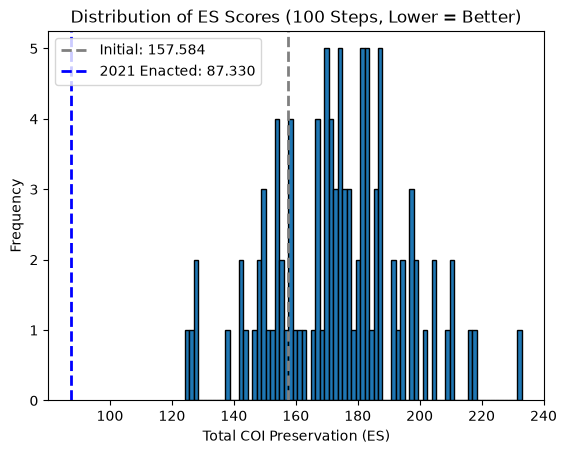

In [30]:
plt.hist(es_scores, bins=75, edgecolor="black")
initial_score = initial_partition["es"]
score_2021 = enacted_2021["es"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2021 Enacted: {score_2021:.3f}",
)


plt.title(f"Distribution of ES Scores ({MARKOV_STEPS} Steps, Lower = Better)")
plt.xlabel("Total COI Preservation (ES)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

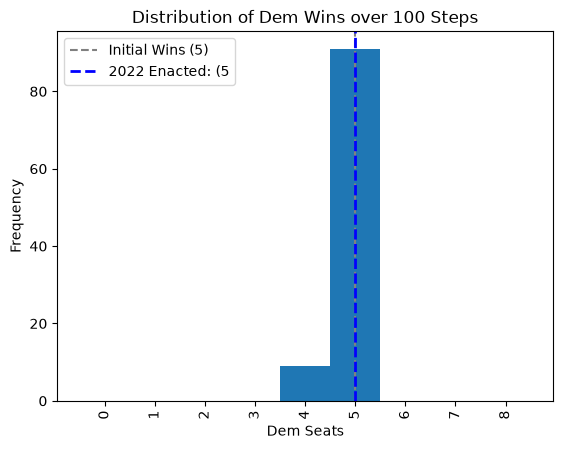

In [31]:
# hist: dem seats distribution
n_districts = len(initial_partition.parts)
plt.hist(
    dem_wins_count, 
    bins=np.arange(-0.5, n_districts + 1.5, 1)
    )
plt.xticks(range(n_districts + 1))
plt.xlabel("Dem Seats")
plt.ylabel("Frequency")
plt.title(f"Distribution of Dem Wins over {MARKOV_STEPS} Steps")

# initial wins line
initial_wins = count_dem_wins(initial_partition)
wins_2021 = count_dem_wins(enacted_2021)

plt.axvline(
    x=initial_wins, 
    color='grey', 
    linestyle='dashed', 
    label=f'Initial Wins ({initial_wins})')

plt.axvline(
    x = wins_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2022 Enacted: ({wins_2021}",
)

plt.xticks(rotation = 'vertical')
plt.legend()
plt.show()

plotting most preserved map:
ES score: 124.237
cut edges: 532
dem seats won: 5/8


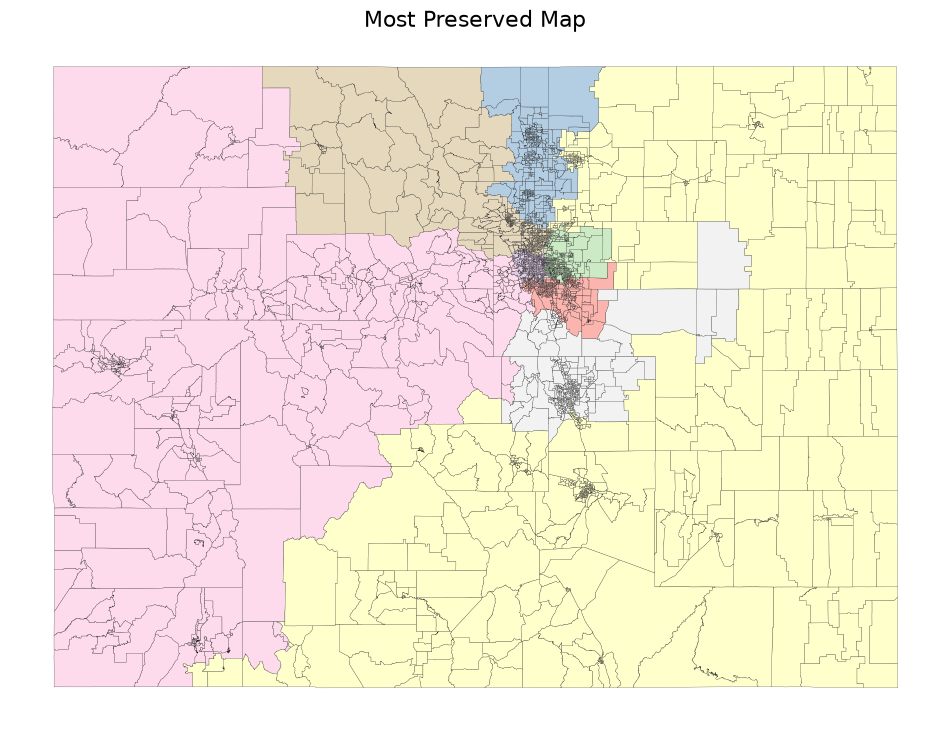

0.7147219711052567


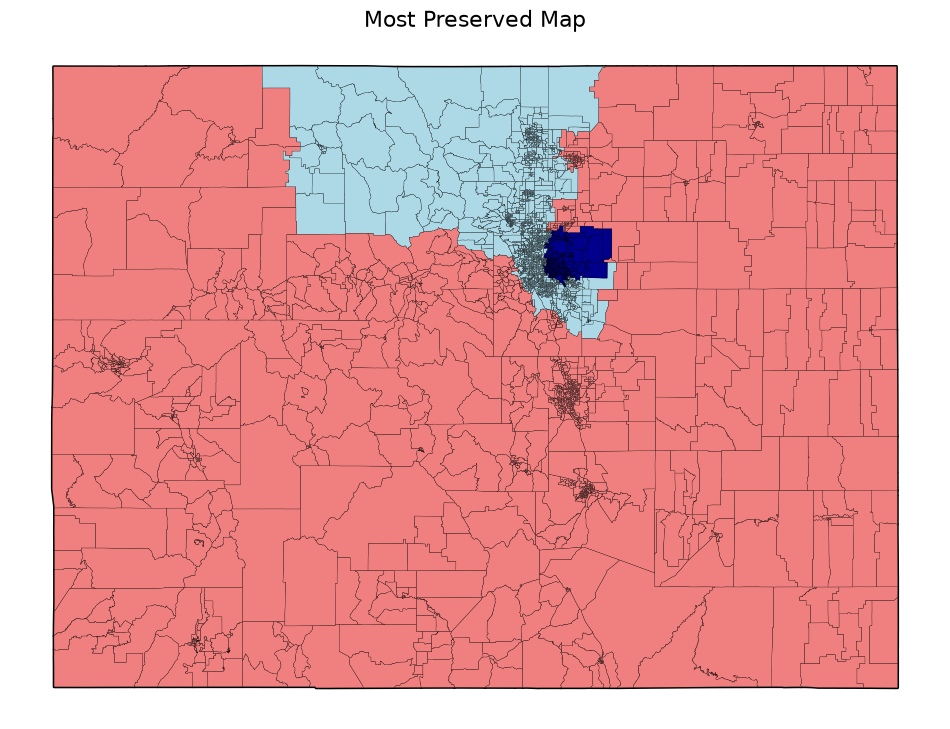

plotting least preserved map:
ES score: 232.933
cut edges: 673
dem seats won: 5/8


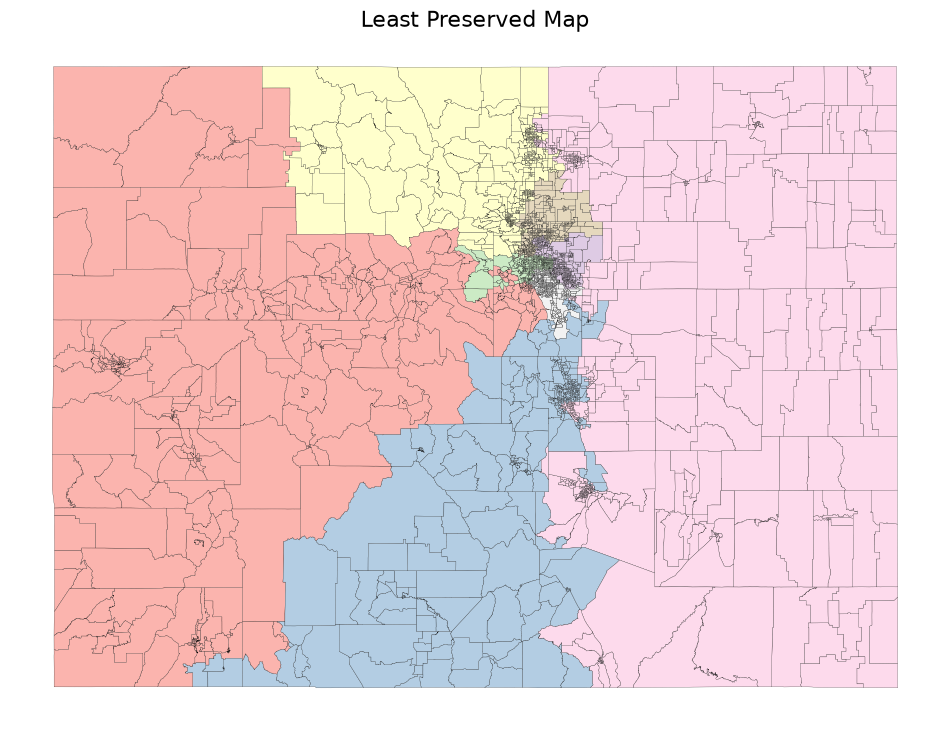

0.7283690484601952


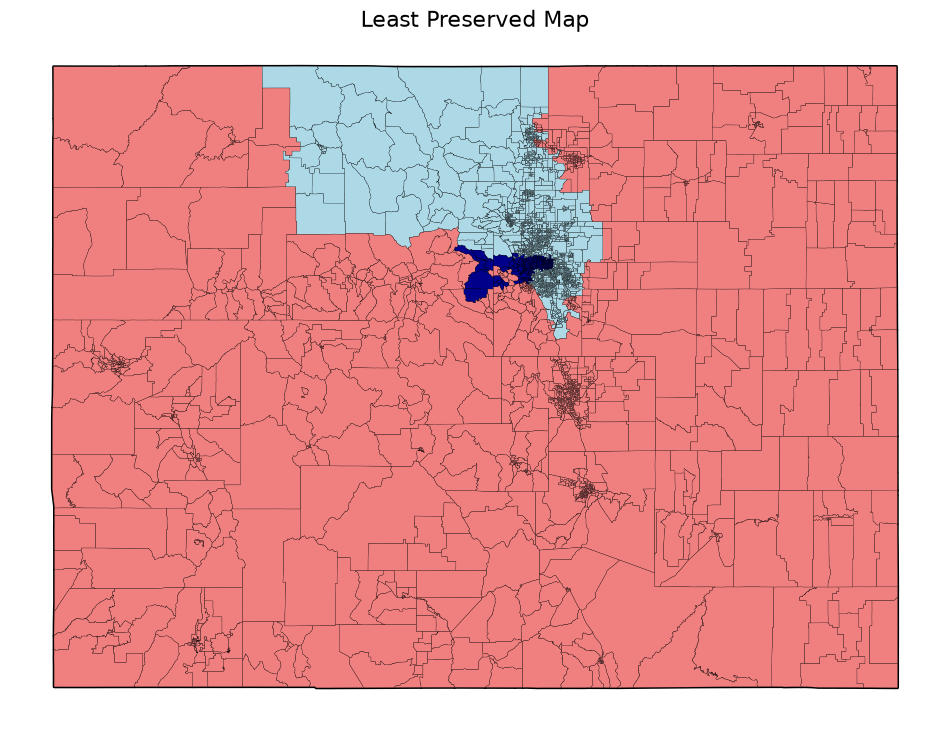

plotting best max representation map:
ES score: 232.933
cut edges: 673
dem seats won: 5/8


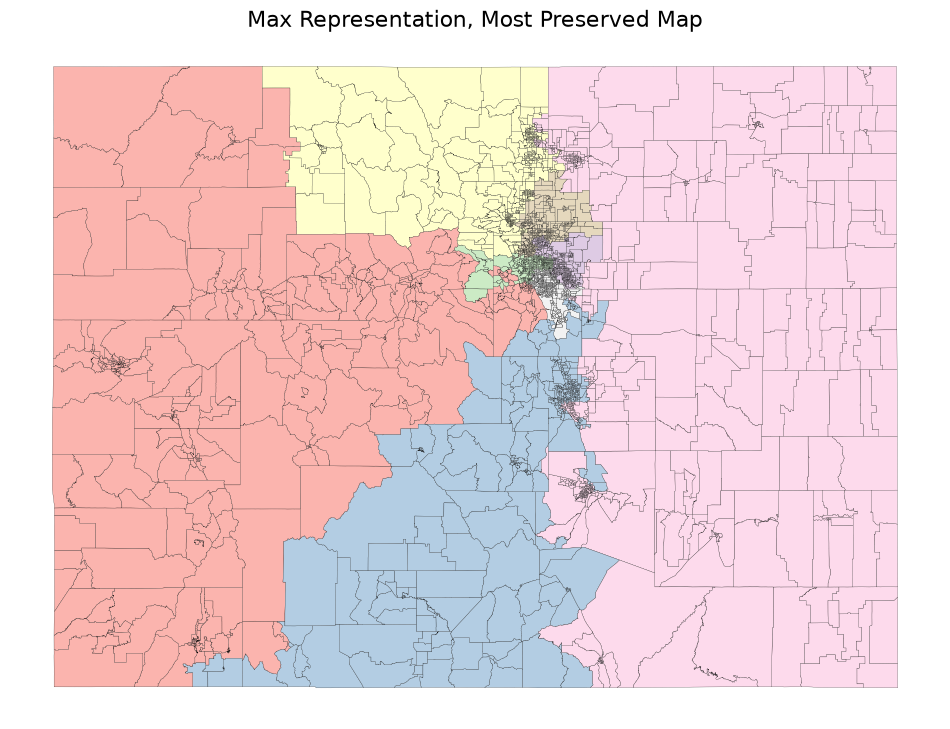

0.7283690484601952


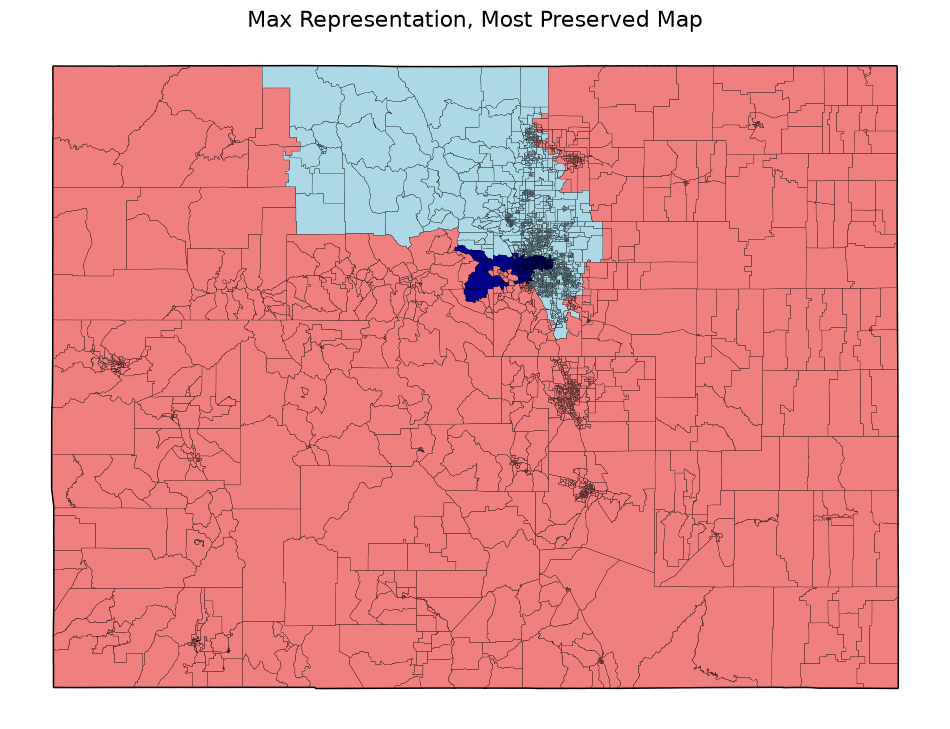

In [34]:

print("plotting most preserved map:")
print(f"ES score: {best_map['es']:.3f}")
print(f"cut edges: {len(best_map['cut_edges'])}")
print(f"dem seats won: {best_map['dem_wins']}/8")
plot_partition(best_map, vtds, cois, 'Most Preserved Map')
plot_partition_party(best_map, vtds, cois, 'Most Preserved Map')


print("plotting least preserved map:")
print(f"ES score: {worst_map['es']:.3f}")
print(f"cut edges: {len(worst_map['cut_edges'])}")
print(f"dem seats won: {worst_map['dem_wins']}/8")
plot_partition(worst_map, vtds, cois, 'Least Preserved Map')
plot_partition_party(worst_map, vtds, cois, 'Least Preserved Map')

print("plotting best max representation map:")
print(f"ES score: {overall_best_map['es']:.3f}")
print(f"cut edges: {len(overall_best_map['cut_edges'])}")
print(f"dem seats won: {overall_best_map['dem_wins']}/8")
plot_partition(overall_best_map, vtds, cois, 'Max Representation, Most Preserved Map')
plot_partition_party(overall_best_map, vtds, cois, 'Max Representation, Most Preserved Map')

